In [1]:
import pandas as pd

# Using the absolute path you specified, so there's no ambiguity about
# which folder pandas is reading from — no dependency on which directory
# your terminal/notebook happens to be running from.
extended_path = r"C:\Users\dahue\Athlete_Career_Intelligence\data\raw\PlayerStatisticsExtended.csv"

# Loading only a small sample first (10 rows) to inspect structure without
# waiting on a 433 MB file load.
extended_sample = pd.read_csv(extended_path, nrows=10)

# Quick sanity checks before we trust this data:
print(f"Number of columns: {len(extended_sample.columns)}")
print(f"Column names:\n{extended_sample.columns.tolist()}")

Number of columns: 110
Column names:
['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst', 'gameType', 'gameLabel', 'gameSubLabel', 'seriesGameNumber', 'win', 'home', 'playerteamId', 'playerteamCity', 'playerteamName', 'opponentteamId', 'opponentteamCity', 'opponentteamName', 'comment', 'startingPosition', 'numMinutes', 'points', 'assists', 'reboundsTotal', 'reboundsOffensive', 'reboundsDefensive', 'fieldGoalsMade', 'fieldGoalsAttempted', 'fieldGoalsPercentage', 'threePointersMade', 'threePointersAttempted', 'threePointersPercentage', 'freeThrowsMade', 'freeThrowsAttempted', 'freeThrowsPercentage', 'steals', 'blocks', 'blocksAgainst', 'turnovers', 'foulsPersonal', 'foulsAgainst', 'plusMinusPoints', 'doubleDouble', 'tripleDouble', 'estimatedOffensiveRating', 'offensiveRating', 'spWorkOffensiveRating', 'estimatedDefensiveRating', 'defensiveRating', 'spWorkDefensiveRating', 'estimatedNetRating', 'netRating', 'spWorkNetRating', 'assistPercentage', 'assistToTurnoverRatio', 'ass

In [2]:
# Printing all 110 column names, one per line, so it's easier to scan
# through them instead of one long wrapped string.
for col in extended_sample.columns:
    print(col)

firstName
lastName
personId
gameId
gameDateTimeEst
gameType
gameLabel
gameSubLabel
seriesGameNumber
win
home
playerteamId
playerteamCity
playerteamName
opponentteamId
opponentteamCity
opponentteamName
comment
startingPosition
numMinutes
points
assists
reboundsTotal
reboundsOffensive
reboundsDefensive
fieldGoalsMade
fieldGoalsAttempted
fieldGoalsPercentage
threePointersMade
threePointersAttempted
threePointersPercentage
freeThrowsMade
freeThrowsAttempted
freeThrowsPercentage
steals
blocks
blocksAgainst
turnovers
foulsPersonal
foulsAgainst
plusMinusPoints
doubleDouble
tripleDouble
estimatedOffensiveRating
offensiveRating
spWorkOffensiveRating
estimatedDefensiveRating
defensiveRating
spWorkDefensiveRating
estimatedNetRating
netRating
spWorkNetRating
assistPercentage
assistToTurnoverRatio
assistRatio
offensiveReboundPercentage
defensiveReboundPercentage
reboundPercentage
teamTurnoverPercentage
estimatedTurnoverPercentage
effectiveFieldGoalPercentage
trueShootingPercentage
usagePercentage
e

In [3]:
columns_needed = [
    "personId", "firstName", "lastName", "gameDateTimeEst", "gameType",  # changed gameDate -> gameDateTimeEst
    "numMinutes", "points", "reboundsTotal", "reboundsOffensive", "reboundsDefensive",
    "assists", "steals", "blocks", "turnovers",
    "fieldGoalsMade", "fieldGoalsAttempted",
    "threePointersMade", "threePointersAttempted",
    "freeThrowsMade", "freeThrowsAttempted",
    "usagePercentage", "assistPercentage",
    "percentPoints3Point", "percentPointsInPaint", "percentPointsFastBreak",
    "percentAssisted3PointMade", "percentAssisted2PointMade",
]
extended_path = r"C:\Users\dahue\Athlete_Career_Intelligence\data\raw\PlayerStatisticsExtended.csv"
df = pd.read_csv(extended_path, usecols=columns_needed)

# --- Step 2: keep regular season only ---
# We haven't seen the exact values of gameType yet — check them first.
print(df["gameType"].unique())

['Playoffs' 'Play-in Tournament' 'Regular Season' 'All-Star Game'
 'Emirates NBA Cup' 'Preseason' 'NBA Emirates Cup' 'Pre Season']


C:\Users\dahue\AppData\Local\Temp\ipykernel_13228\914794297.py:13: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(extended_path, usecols=columns_needed)


In [4]:
# This forces pandas to scan the whole file in one pass instead of chunks,
# which resolves the ambiguity warning and gives us reliable dtypes.
df = pd.read_csv(extended_path, usecols=columns_needed, low_memory=False)

# Check the resulting data type of each column
print(df.dtypes)

firstName                     object
lastName                      object
personId                       int64
gameDateTimeEst               object
gameType                      object
numMinutes                    object
points                       float64
assists                      float64
reboundsTotal                float64
reboundsOffensive            float64
reboundsDefensive            float64
fieldGoalsMade               float64
fieldGoalsAttempted          float64
threePointersMade            float64
threePointersAttempted       float64
freeThrowsMade               float64
freeThrowsAttempted          float64
steals                       float64
blocks                       float64
turnovers                    float64
assistPercentage             float64
usagePercentage              float64
percentPoints3Point          float64
percentPointsFastBreak       float64
percentPointsInPaint         float64
percentAssisted2PointMade    float64
percentAssisted3PointMade    float64
d

In [5]:
# Sampling 20 raw values from numMinutes to see what formats are actually in there
print(df["numMinutes"].sample(20, random_state=42))

# Also checking specifically for null/missing values, since those often
# explain why a numeric-looking column ends up typed as "object"
print(f"\nNull values: {df['numMinutes'].isnull().sum()} out of {len(df)}")

181194      NaN
10915     18.51
581207      3.0
14047     31.21
208245     31.0
362778      7.0
455482     30.0
533469     36.0
643442     27.0
145516     13.0
211689     30.0
3426      34.17
471919     35.0
219537     27.0
237911     27.0
537375     21.0
14678     15.09
732895      9.0
441432      6.0
457852     29.0
Name: numMinutes, dtype: object

Null values: 1257 out of 838803


In [6]:
# errors="coerce" tells pandas: try to convert every value to a number,
# and for anything that fails, replace it with NaN instead of crashing.
numeric_attempt = pd.to_numeric(df["numMinutes"], errors="coerce")

# Now we compare: any row that is NaN in numeric_attempt but was NOT NaN
# in the original column must be a value that failed conversion — i.e.,
# something that isn't a clean number.
problematic_mask = numeric_attempt.isnull() & df["numMinutes"].notnull()

print(f"Problematic values found: {problematic_mask.sum()}")
print(df.loc[problematic_mask, "numMinutes"].unique())

Problematic values found: 2096
['6:08' '19:19' '16:49' ... '36:16' '3:42' '15:07']


In [7]:
def convert_minutes(value):
    """
    Converts a numMinutes value into a clean float representing minutes played.

    Handles two formats found in this column:
      - Decimal minutes as text or number, e.g. 18.51 or "18.51"
      - "MM:SS" format as text, e.g. "6:08" (6 minutes, 8 seconds)

    Returns float("nan") for missing values, so they stay as proper
    NaN and don't silently become 0 (which would be misleading —
    a missing value is not the same as "played zero minutes").
    """
    # --- Case 1: missing value ---
    # pd.isna() correctly detects NaN even though, at this point, `value`
    # could technically be a float, a string, or actually missing —
    # this check has to come first, before we try any string operations,
    # because calling .split() on a NaN would raise an error.
    if pd.isna(value):
        return float("nan")

    # --- Case 2: "MM:SS" format ---
    # We only reach this branch if value is NOT missing. Checking for ":"
    # tells us whether we're dealing with the "MM:SS" text format.
    if ":" in str(value):
        minutes_part, seconds_part = str(value).split(":")
        # Converting each piece to a number, then combining them into
        # a single decimal value: e.g. "6:08" -> 6 + 8/60 = 6.1333...
        return int(minutes_part) + int(seconds_part) / 60

    # --- Case 3: already a plain number (as float or as numeric string) ---
    # float() handles both cases directly: float(18.51) -> 18.51,
    # and float("18.51") -> 18.51 as well.
    return float(value)


# Applying the function to every row in the column.
# .apply() runs convert_minutes() once per value in the Series and
# collects the results into a new Series of the same length.
df["numMinutes_clean"] = df["numMinutes"].apply(convert_minutes)

# --- Verification: confirm no string values remain ---
# isinstance(x, str) checks, for each value, whether it's still a
# leftover string (meaning our conversion missed something).
# .sum() on a boolean Series counts how many True values there are —
# we expect this to print 0 if the conversion worked correctly.
remaining_strings = df["numMinutes_clean"].apply(lambda x: isinstance(x, str)).sum()
print(f"Remaining string values (should be 0): {remaining_strings}")

# --- Sanity check: compare a few converted "MM:SS" values against the originals ---
# Filtering the original column for rows that had the ":" format, and
# showing both the original and converted value side by side, so you can
# visually confirm the math is right (e.g. "6:08" should now read ~6.13).
mmss_mask = df["numMinutes"].astype(str).str.contains(":", na=False)
print(df.loc[mmss_mask, ["numMinutes", "numMinutes_clean"]].head(10))

Remaining string values (should be 0): 0
       numMinutes  numMinutes_clean
836707       6:08          6.133333
836708      19:19         19.316667
836709      16:49         16.816667
836710       6:05          6.083333
836711      16:17         16.283333
836712      25:04         25.066667
836713       8:27          8.450000
836714       8:02          8.033333
836715      16:22         16.366667
836716      19:35         19.583333


In [8]:
import numpy as np
import pandas as pd

# --- Step 1: keep only Regular Season games ---
df_regular = df[df["gameType"] == "Regular Season"].copy()

# --- Step 2: parse the datetime column into a real date ---
df_regular["gameDateTimeEst"] = pd.to_datetime(df_regular["gameDateTimeEst"])

# --- Step 3: derive the NBA season label from the date ---
def get_season(date):
    if date.month >= 10:
        start_year = date.year
    else:
        start_year = date.year - 1
    end_year_short = str(start_year + 1)[-2:]
    return f"{start_year}-{end_year_short}"

df_regular["season"] = df_regular["gameDateTimeEst"].apply(get_season)

# --- Step 4: aggregate game-by-game rows into one row per player per season ---
grouped = df_regular.groupby(["personId", "season"])

season_stats = grouped.agg(
    firstName=("firstName", "first"),
    lastName=("lastName", "first"),
    games_played=("personId", "count"),
    avg_minutes=("numMinutes_clean", "mean"),
    points_pg=("points", "mean"),
    rebounds_pg=("reboundsTotal", "mean"),
    assists_pg=("assists", "mean"),
    steals_pg=("steals", "mean"),
    blocks_pg=("blocks", "mean"),
    turnovers_pg=("turnovers", "mean"),
    fgm_total=("fieldGoalsMade", "sum"),
    fga_total=("fieldGoalsAttempted", "sum"),
    tpm_total=("threePointersMade", "sum"),
    tpa_total=("threePointersAttempted", "sum"),
    ftm_total=("freeThrowsMade", "sum"),
    fta_total=("freeThrowsAttempted", "sum"),
).reset_index()

# --- Step 5: recomputed shooting percentages ---
season_stats["fg_pct"] = np.where(season_stats["fga_total"] > 0, season_stats["fgm_total"] / season_stats["fga_total"], np.nan)
season_stats["tp_pct"] = np.where(season_stats["tpa_total"] > 0, season_stats["tpm_total"] / season_stats["tpa_total"], np.nan)
season_stats["ft_pct"] = np.where(season_stats["fta_total"] > 0, season_stats["ftm_total"] / season_stats["fta_total"], np.nan)

# --- Step 6: weighted averages for advanced percentage columns ---
def weighted_avg(group, value_col, weight_col="numMinutes_clean"):
    valid = group.dropna(subset=[value_col])
    if valid[weight_col].sum() == 0:
        return np.nan
    return (valid[value_col] * valid[weight_col]).sum() / valid[weight_col].sum()

weighted_cols = ["usagePercentage", "assistPercentage",
                  "percentPoints3Point", "percentPointsInPaint", "percentPointsFastBreak",
                  "percentAssisted3PointMade", "percentAssisted2PointMade"]

weighted_results = []
for col in weighted_cols:
    result = df_regular.groupby(["personId", "season"]).apply(
        lambda g: weighted_avg(g, col),
        include_groups=False
    )
    result.name = col + "_wavg"
    weighted_results.append(result)

weighted_df = pd.concat(weighted_results, axis=1).reset_index()
season_stats = season_stats.merge(weighted_df, on=["personId", "season"], how="left")

print(f"season_stats shape: {season_stats.shape}")
print(season_stats.columns.tolist())

season_stats shape: (14569, 28)
['personId', 'season', 'firstName', 'lastName', 'games_played', 'avg_minutes', 'points_pg', 'rebounds_pg', 'assists_pg', 'steals_pg', 'blocks_pg', 'turnovers_pg', 'fgm_total', 'fga_total', 'tpm_total', 'tpa_total', 'ftm_total', 'fta_total', 'fg_pct', 'tp_pct', 'ft_pct', 'usagePercentage_wavg', 'assistPercentage_wavg', 'percentPoints3Point_wavg', 'percentPointsInPaint_wavg', 'percentPointsFastBreak_wavg', 'percentAssisted3PointMade_wavg', 'percentAssisted2PointMade_wavg']


In [9]:
# --- Recomputing shooting percentages from season totals ---
# This is the mathematically correct approach we discussed: dividing the
# SUM of makes by the SUM of attempts for the whole season, rather than
# averaging each game's percentage.
#
# np.where() is used instead of a plain division to handle players with
# zero attempts all season (e.g. a center who never once tried a 3-pointer) —
# dividing by zero would otherwise produce an error or a confusing "inf" value.
# np.where(condition, value_if_true, value_if_false) checks the condition
# for every row at once.
season_stats["fg_pct"] = np.where(
    season_stats["fga_total"] > 0,
    season_stats["fgm_total"] / season_stats["fga_total"],
    np.nan  # if a player never attempted a shot, the percentage is undefined, not 0
)

season_stats["tp_pct"] = np.where(
    season_stats["tpa_total"] > 0,
    season_stats["tpm_total"] / season_stats["tpa_total"],
    np.nan
)

season_stats["ft_pct"] = np.where(
    season_stats["fta_total"] > 0,
    season_stats["ftm_total"] / season_stats["fta_total"],
    np.nan
)

# --- Weighted averages for the advanced percentage columns ---
# These (usagePercentage, assistPercentage, and the "percentPoints*" family)
# don't have a simple "made/attempted" pair behind them, so we can't
# recompute them from raw totals like we just did above. Instead, we weight
# each game's value by the minutes played that game, so a 35-minute game
# counts more than a 4-minute one.
#
# We can't use .agg() with a simple "mean" for this — we need a custom
# calculation per group, so we build a small helper function and apply it
# with .apply() on the grouped data instead.
def weighted_avg(group, value_col, weight_col="numMinutes_clean"):
    # Dropping rows where the value itself is missing, so they don't
    # distort the weighted average.
    valid = group.dropna(subset=[value_col])
    if valid[weight_col].sum() == 0:
        return np.nan
    return (valid[value_col] * valid[weight_col]).sum() / valid[weight_col].sum()

# Re-grouping the ORIGINAL game-level data (df_regular), not season_stats,
# because we need access to the individual game rows to compute the
# weighted average — season_stats already collapsed that detail away.
weighted_cols = ["usagePercentage", "assistPercentage",
                  "percentPoints3Point", "percentPointsInPaint", "percentPointsFastBreak",
                  "percentAssisted3PointMade", "percentAssisted2PointMade"]

weighted_results = []
for col in weighted_cols:
    result = df_regular.groupby(["personId", "season"]).apply(
    lambda g: weighted_avg(g, col),
    include_groups=False
)
    result.name = col + "_wavg"
    weighted_results.append(result)

# Combining all the weighted-average Series into a single DataFrame, then
# merging it onto season_stats using personId + season as the shared key.
weighted_df = pd.concat(weighted_results, axis=1).reset_index()
season_stats = season_stats.merge(weighted_df, on=["personId", "season"], how="left")

print(season_stats.head(10))
print(f"\nFinal shape: {season_stats.shape}")

   personId   season firstName lastName  games_played  avg_minutes  points_pg  \
0         2  1996-97     Byron    Scott            79    17.721519   6.658228   
1         3  1996-97     Grant     Long            65    17.553846   5.015385   
2         3  1997-98     Grant     Long            40    18.125000   3.525000   
3         3  1998-99     Grant     Long            50    27.120000   9.780000   
4         3  1999-00     Grant     Long            42    21.476190   4.833333   
5         3  2000-01     Grant     Long            66    22.393939   6.000000   
6         3  2001-02     Grant     Long            66    27.772727   6.318182   
7         3  2002-03     Grant     Long            41    11.414634   1.756098   
8         7  1996-97       Dan  Schayes            45    11.511111   2.955556   
9         7  1997-98       Dan  Schayes            74    16.729730   5.486486   

   rebounds_pg  assists_pg  steals_pg  ...  percentPointsFastBreak_wavg_x  \
0     1.493671    1.253165   0.

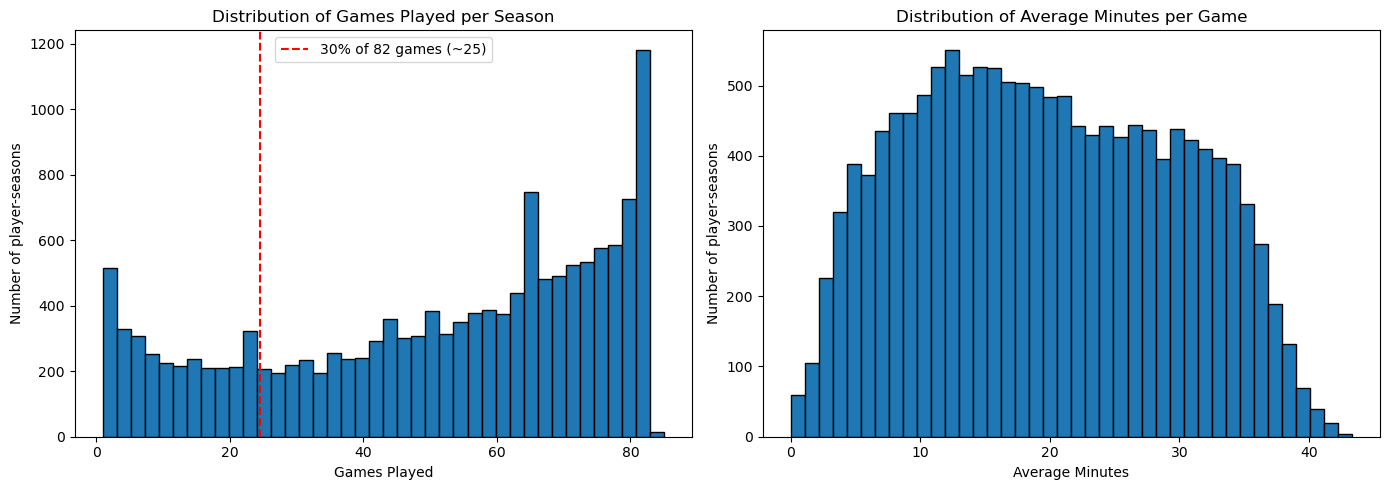

games_played percentiles:
count    14569.000000
mean        50.440593
std         25.086641
min          1.000000
10%         10.000000
25%         30.000000
50%         56.000000
75%         72.000000
90%         80.000000
max         85.000000
Name: games_played, dtype: float64

avg_minutes percentiles:
count    14569.000000
mean        19.638388
std          9.927205
min          0.000000
10%          6.444444
25%         11.500000
50%         19.071429
75%         27.818182
90%         33.527937
max         43.316667
Name: avg_minutes, dtype: float64


In [10]:
import matplotlib.pyplot as plt

# Creating two histograms side by side, one for games played and one for
# average minutes per game — this lets us visually spot natural cutoff
# points in the distribution instead of picking thresholds arbitrarily.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram 1: games played ---
axes[0].hist(season_stats["games_played"], bins=40, edgecolor="black")
axes[0].set_title("Distribution of Games Played per Season")
axes[0].set_xlabel("Games Played")
axes[0].set_ylabel("Number of player-seasons")
# Adding a vertical reference line at 30% of an 82-game season (~25 games),
# just as a visual anchor — not a final decision yet.
axes[0].axvline(x=82 * 0.3, color="red", linestyle="--", label="30% of 82 games (~25)")
axes[0].legend()

# --- Histogram 2: average minutes per game ---
axes[1].hist(season_stats["avg_minutes"], bins=40, edgecolor="black")
axes[1].set_title("Distribution of Average Minutes per Game")
axes[1].set_xlabel("Average Minutes")
axes[1].set_ylabel("Number of player-seasons")

plt.tight_layout()  # prevents titles/labels from overlapping between the two plots
plt.show()

# Also printing some descriptive statistics as numbers, since histograms
# can be hard to read precisely — percentiles help pick a concrete cutoff.
print("games_played percentiles:")
print(season_stats["games_played"].describe(percentiles=[.1, .25, .5, .75, .9]))

print("\navg_minutes percentiles:")
print(season_stats["avg_minutes"].describe(percentiles=[.1, .25, .5, .75, .9]))